# Phase 6: Exploratory analysis and maps (SQ1)

In this notebook we look at how car ownership, distance to the nearest station and train disruptions are spread across Dutch neighbourhoods in 2023. This answers SQ1. We use maps (GeoPandas, as in the lecture) and simple charts.

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROCESSED = Path('data/cleaned_data')

# Load the master table (Phase 5), the neighbourhood map and the stations
master = pd.read_pickle(PROCESSED / 'master.pkl')
buurten_kaart = gpd.read_file(PROCESSED / 'buurten_kaart.gpkg')
stations = pd.read_pickle(PROCESSED / 'stations.pkl')

c:\Users\alecm\anaconda3\envs\TIL6022-26\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## Step 1: Summary statistics
A quick overview of the main variables.

In [2]:
master[['autos_per_hh', 'afstand_station', 'storingen_per_jaar', 'minuten_per_jaar']].describe().round(2)

,autos_per_hh,afstand_station,storingen_per_jaar,minuten_per_jaar
count,11221.00,11221.00,11221.00,11221.00
mean,1.16,6.39,66.80,13711.70
std,0.36,6.82,62.58,14034.43
min,0.00,0.10,2.00,355.67
25%,0.90,2.00,27.00,4686.33
50%,1.20,4.20,45.33,10390.67
75%,1.40,8.30,90.00,15891.33
max,2.50,58.00,535.33,100046.33


## Step 2: Put the data on the map
The master table has no shapes, and the map has no numbers. We join them using the neighbourhood code, so every shape gets its numbers.

In [3]:
# Add the numbers from the master table to the shapes on the map
kaart = buurten_kaart.merge(master, on='buurtcode')

print(len(kaart))

11221


## Step 3: Map of car ownership
Each neighbourhood is coloured by the number of cars per household. Neighbourhoods that are not in our sample (for example business zones or areas without data) are shown in light grey.

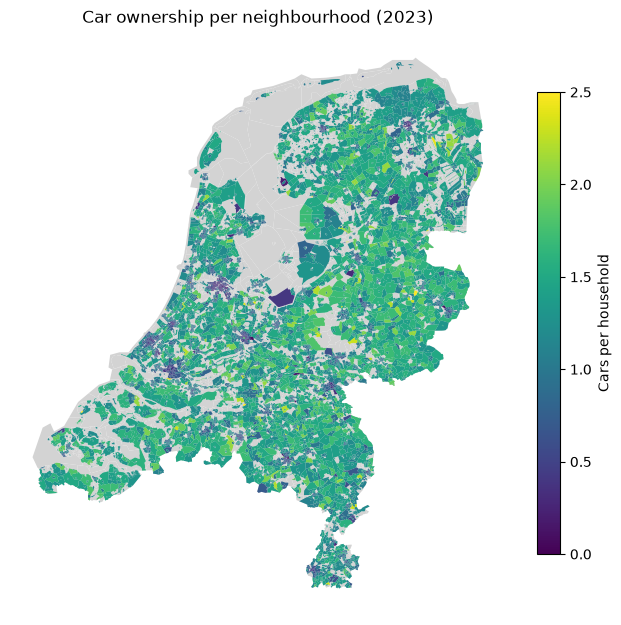

In [4]:
# Draw all neighbourhoods in light grey as a background
ax = buurten_kaart.plot(color='lightgrey', figsize=(8, 10))

# Draw our neighbourhoods on top, coloured by car ownership
kaart.plot(ax=ax, column='autos_per_hh', cmap='viridis', legend=True,
           legend_kwds={'label': 'Cars per household', 'shrink': 0.6})

ax.set_title('Car ownership per neighbourhood (2023)')
ax.set_axis_off()   # hide the coordinates around the map
plt.show()

## Step 4: Stations on top of the map
We add the railway stations as dots: red for major stations and blue for minor stations. This shows whether car ownership is lower around stations.

In [5]:
# Step 4a: turn the station coordinates into points (same as in Phase 3)
punten = gpd.points_from_xy(stations['geo_lng'], stations['geo_lat'])
station_punten = gpd.GeoDataFrame(stations, geometry=punten, crs='EPSG:4326')
station_punten = station_punten.to_crs('EPSG:28992')

# Step 4b: split into major and minor stations (same grouping as in Phase 3)
grote_types = ['megastation', 'knooppuntIntercitystation', 'intercitystation']
grote = station_punten[station_punten['type'].isin(grote_types)]
kleine = station_punten[~station_punten['type'].isin(grote_types)]

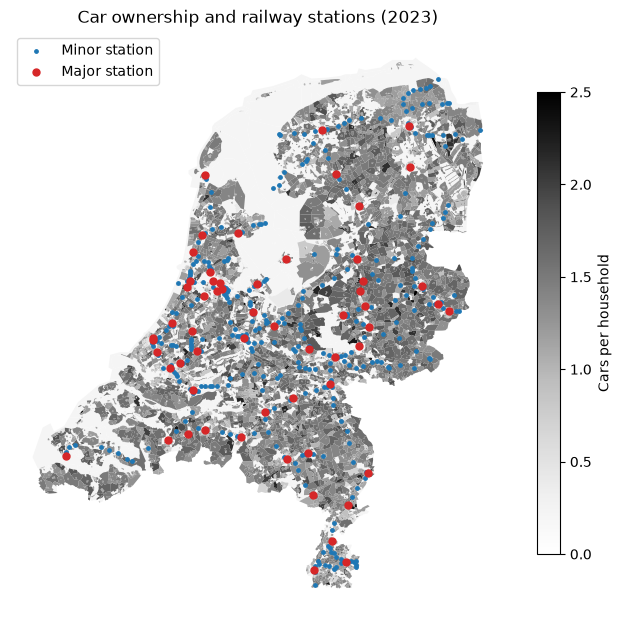

In [6]:
# Background: car ownership in grey tones, so the coloured dots stand out
ax = buurten_kaart.plot(color='whitesmoke', figsize=(8, 10))
kaart.plot(ax=ax, column='autos_per_hh', cmap='Greys', legend=True,
           legend_kwds={'label': 'Cars per household', 'shrink': 0.6})

# Stations on top
kleine.plot(ax=ax, color='tab:blue', markersize=6, label='Minor station')
grote.plot(ax=ax, color='tab:red', markersize=25, label='Major station')

ax.set_title('Car ownership and railway stations (2023)')
ax.legend(loc='upper left')
ax.set_axis_off()
plt.show()

## Step 5: Car ownership by distance to the station
We put the neighbourhoods in groups by distance to the nearest station and calculate the average car ownership per group. This is easier to read than a scatter plot with 11,000 dots.

In [7]:
# Make distance groups: 0-1 km, 1-2 km, 2-3 km, 3-5 km, 5-10 km, 10-20 km, more than 20 km
grenzen = [0, 1, 2, 3, 5, 10, 20, 60]
master['afstand_groep'] = pd.cut(master['afstand_station'], bins=grenzen)

# Average car ownership per group
gemiddelde = master.groupby('afstand_groep', observed=True)['autos_per_hh'].mean()

# How many neighbourhoods are in each group
aantal = master['afstand_groep'].value_counts().sort_index()

print(pd.DataFrame({'avg cars per household': gemiddelde.round(2), 'neighbourhoods': aantal}))

               avg cars per household  neighbourhoods
afstand_groep                                        
(0, 1]                           0.93             848
(1, 2]                           0.94            1978
(2, 3]                           1.03            1604
(3, 5]                           1.19            1935
(5, 10]                          1.31            2674
(10, 20]                         1.34            1725
(20, 60]                         1.31             457


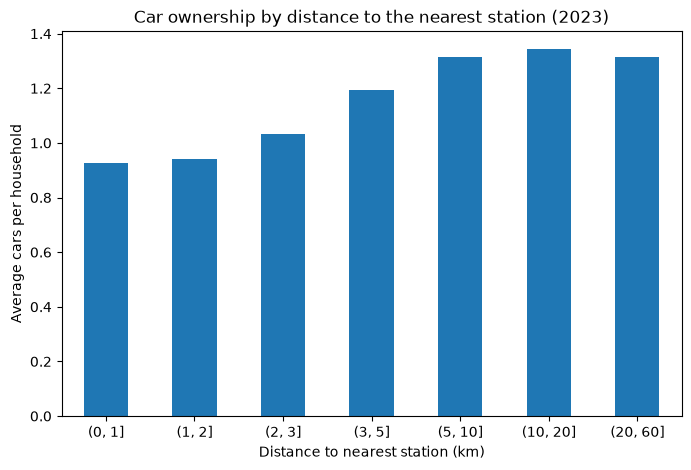

In [8]:
ax = gemiddelde.plot(kind='bar', color='tab:blue', figsize=(8, 5))

ax.set_xlabel('Distance to nearest station (km)')
ax.set_ylabel('Average cars per household')
ax.set_title('Car ownership by distance to the nearest station (2023)')
plt.xticks(rotation=0)
plt.show()

## Step 6: Train disruptions per station
Each station is shown as a dot. The colour shows the average number of disruptions per year (2021–2023).

In [9]:
# Add the number of disruptions to each station (from the master table)
storingen = master[['station_code', 'storingen_per_jaar']].drop_duplicates()
station_punten = station_punten.merge(storingen, left_on='code', right_on='station_code', how='left')

# Stations that are not the nearest station of any neighbourhood have no value; we leave them out
station_punten = station_punten[station_punten['storingen_per_jaar'].notna()]

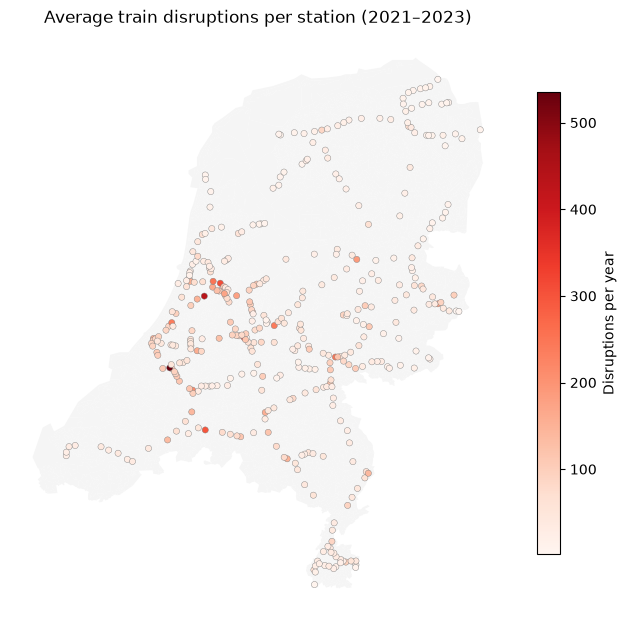

In [10]:
ax = buurten_kaart.plot(color='whitesmoke', edgecolor='none', figsize=(8, 10))

station_punten.plot(ax=ax, column='storingen_per_jaar', cmap='Reds', markersize=20, edgecolor='grey', linewidth=0.3, legend=True,
                    legend_kwds={'label': 'Disruptions per year', 'shrink': 0.6})

ax.set_title('Average train disruptions per station (2021–2023)')
ax.set_axis_off()
plt.show()

In [11]:
# The 10 stations with the most disruptions
station_punten.sort_values('storingen_per_jaar', ascending=False)[['name_long', 'type', 'storingen_per_jaar']].head(10)

,name_long,type,storingen_per_jaar
288,Rotterdam Centraal,megastation,535.333333
303,Schiphol Airport,megastation,433.333333
330,Utrecht Centraal,megastation,355.666667
22,Amsterdam Centraal,megastation,311.000000
68,Breda,knooppuntIntercitystation,299.333333
37,Arnhem Centraal,knooppuntIntercitystation,251.666667
28,Amsterdam Sloterdijk,knooppuntIntercitystation,251.000000
17,Amersfoort Centraal,knooppuntIntercitystation,241.000000
226,Leiden Centraal,knooppuntIntercitystation,239.000000
111,Dordrecht,knooppuntIntercitystation,215.666667


## Findings (SQ1)

*Fill in after running the notebook. Points to mention:*
- Car ownership is lowest in the big cities and highest in rural areas.
- Average car ownership rises from about 0.9 cars per household within 1 km of a station to about 1.3 beyond 5 km.
- Neighbourhoods near major stations have lower car ownership (about 1.0) than near minor stations (about 1.2).
- Disruptions are concentrated at the large stations in the Randstad (Rotterdam Centraal, Schiphol, Utrecht Centraal, Amsterdam Centraal).